In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from depth_anything_3.api import DepthAnything3
from depth_anything_3.utils.visualize import visualize_depth
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DepthAnything3.from_pretrained("depth-anything/DA3METRIC-LARGE")
model = model.to(device)
model.eval()
print(f"Model loaded on {device}")

[WARN ] Dependency `gsplat` is required for rendering 3DGS. Install via: pip install git+https://github.com/nerfstudio-project/gsplat.git@0b4dddf04cb687367602c01196913cde6a743d70


config.json:   0%|          | 0.00/847 [00:00<?, ?B/s]

W0527 09:56:13.433000 21500 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
A matching Triton is not available, some optimizations will not be enabled
Traceback (most recent call last):
  File "c:\Users\lin40269\Desktop\Linh (Desktop)\01_Python\realsense\.venv\Lib\site-packages\xformers\__init__.py", line 57, in _is_triton_available
    import triton  # noqa
    ^^^^^^^^^^^^^
ModuleNotFoundError: No module named 'triton'


[INFO ] using MLP layer as FFN


model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Model loaded on cuda


In [4]:
# Load sample images and run inference
image_paths = [
    r"C:\Users\lin40269\Desktop\Linh (Desktop)\01_Python\realsense\data\realsense_image\test_da3_Color.png"
]

# Run inference
prediction = model.inference(
    image=image_paths,
    process_res=504,
    process_res_method="upper_bound_resize",
    export_dir=None,
    export_format="glb"
)
print(f"Depth shape: {prediction.depth.shape}")
print(f"Extrinsics: {prediction.extrinsics.shape if prediction.extrinsics is not None else 'None'}")
print(f"Intrinsics: {prediction.intrinsics.shape if prediction.intrinsics is not None else 'None'}")

[INFO ] Processed Images Done taking 0.08453011512756348 seconds. Shape:  torch.Size([1, 3, 378, 504])
[INFO ] Model Forward Pass Done. Time: 0.9888777732849121 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0 seconds
Depth shape: (1, 378, 504)
Extrinsics: None
Intrinsics: None


0.2174626737833023


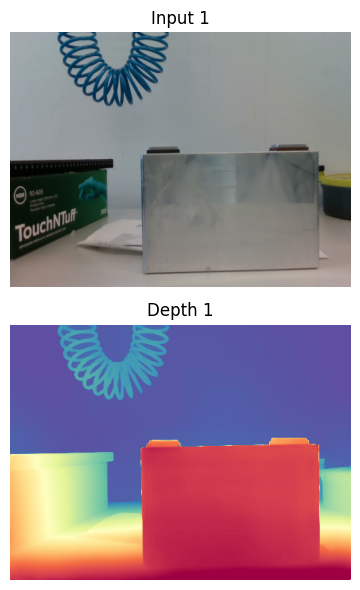

In [8]:
# Visualize input images and depth maps
n_images = prediction.depth.shape[0]
raw_depth = prediction.depth[0]

depth_m = 300 * raw_depth / 300
center_depth = float(depth_m[320, 240])
print(center_depth)
fig, axes = plt.subplots(2, n_images, figsize=(12, 6))

if n_images == 1:
    axes = axes.reshape(2, 1)

for i in range(n_images):
    # Show original image
    if prediction.processed_images is not None:
        axes[0, i].imshow(prediction.processed_images[i])
    axes[0, i].set_title(f"Input {i+1}")
    axes[0, i].axis('off')
    
    # Show depth map
    depth_vis = visualize_depth(prediction.depth[i], cmap="Spectral")
    axes[1, i].imshow(depth_vis)
    axes[1, i].set_title(f"Depth {i+1}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()